# Deep Learning Project – Fashion MNIST

## Fokusområde: Input och Preprocessing

Syftet med detta projekt är att undersöka hur preprocessing påverkar en deep learning-modell för bildklassificering.

Vi använder Fashion MNIST-datasetet som innehåller bilder av olika klädesplagg.

Projektet fokuserar på:

- att förstå datan
- att förbereda input-data
- att analysera hur preprocessing påverkar modellens prestanda

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist


# Ladda in datasetet

Fashion MNIST finns direkt inbyggt i Keras och kan laddas automatiskt.

Datasetet innehåller:

- 60 000 träningsbilder
- 10 000 testbilder
- 10 olika klasser
- gråskalebilder med storlek 28x28 pixlar

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Undersöka datasetets struktur

Vi börjar med att undersöka:

- hur många bilder som finns
- bildstorlek
- hur labels ser ut

In [3]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


# Klassnamn

Fashion MNIST innehåller 10 olika kategorier av kläder och accessoarer.

In [4]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Visualisering av bilder

För att förstå datan bättre visualiserar vi några exempelbilder från datasetet.

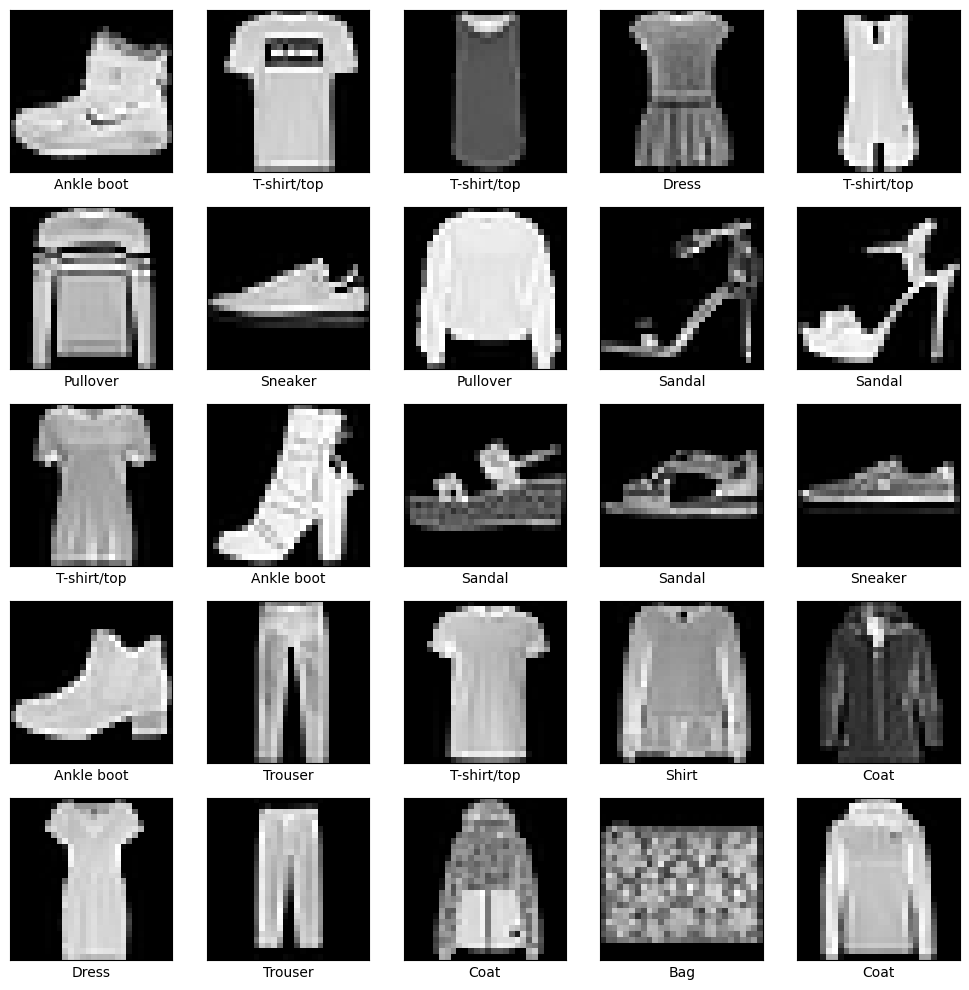

In [5]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_train[i], cmap='gray')
    plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()

# Analys av klassfördelning

Det är viktigt att kontrollera om datasetet är balanserat.

Om vissa klasser innehåller betydligt fler bilder än andra kan modellen bli biased.

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


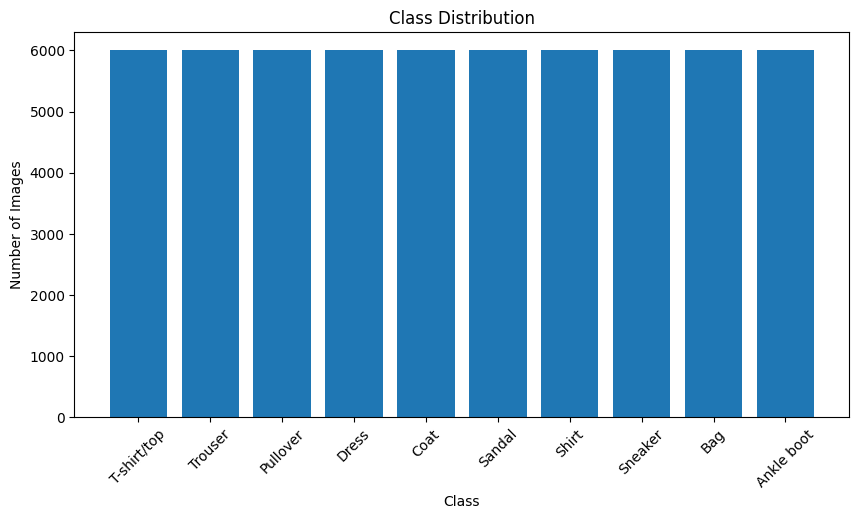

In [7]:
plt.figure(figsize=(10,5))

plt.bar(range(len(unique)), counts)

plt.xticks(range(len(unique)), class_names, rotation=45)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

# Analys av datasetet

Efter analysen kan vi se att:

- datasetet innehåller 10 klasser
- bilderna är gråskalebilder
- alla bilder har storleken 28x28
- datasetet är relativt balanserat

Detta är positivt eftersom balanserad data minskar risken för bias i modellen.

# Preprocessing av data

Innan datan används i en neural nätverksmodell behöver den preprocessas.

Preprocessing hjälper modellen att:

- träna stabilare
- lära sig snabbare
- förbättra prestanda

# Normalisering

Pixelvärden i bilderna ligger mellan 0 och 255.

Neurala nätverk fungerar bättre när värden skalas mellan 0 och 1.

Därför normaliserar vi bilderna genom att dividera med 255.

In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


# Reshape för CNN

CNN-modeller förväntar sig input-data i formatet:

(samples, height, width, channels)

Eftersom bilderna är gråskalebilder lägger vi till en kanal-dimension.

In [10]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [11]:
print("New training shape:", x_train.shape)
print("New test shape:", x_test.shape)

New training shape: (60000, 28, 28, 1)
New test shape: (10000, 28, 28, 1)


# Slutsats

I denna del av projektet har vi:

- undersökt datasetet
- analyserat klassfördelning
- normaliserat bilderna
- förberett datan för CNN-modellen

Preprocessing är viktigt eftersom kvaliteten på input-data påverkar modellens resultat.

## Bygger en modell

Nu när datan är förberedd och normaliserad bygger vi vår modell.
Modellen ska ta en bild som input -- analyserar innehållet -- förutsäger rätt klass.

In [13]:
    # Importerar nödvändiga bibliotek
import tensorflow as tf
from tensorflow import keras

    # Bygger modellen med sequential API
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),     # input: höjd, bredd, kanal

 #    1a convulsion block
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),   # 32 filter, kernel 3x3
    keras.layers.MaxPooling2D((2, 2)),                    # här halveras höjd och bredd

 #    2a convulsion block
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),  # 64 filter
    keras.layers.MaxPooling2D((2, 2)),

 #    Flatten + Dense-lager för klassificering
    keras.layers.Flatten(),                              # gör om feature maps till vektor
    keras.layers.Dense(64, activation='relu'),          # fullt kopplat lager
    keras.layers.Dense(10, activation='softmax')       # 10 klasser -- softmax
])

    # Kompilera modellen (Adam, sparse_categorical_crossentropy, accuracy)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

    # Kontrollpunkt: visa modellens arkitektur
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)